In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [8]:
# Exemple : ton fichier CSV
data = pd.read_csv("C:/Users/Kevin Byamungu/OneDrive/Documents/GitHub/Projet-tutore/Palmares/fichier finale.csv",sep=';')

# Afficher les premières lignes
print(data.head())


   Id  CodeEcole2                               Ecole  \
0   1    41003017                                 NaN   
1   2    41003027  COMPLEXE SCOLLEGEAIRE WIDAL SCHOOL   
2   3    41004012              COLLEGEEGE ABBE LIOSSO   
3   4    41004026                                 NaN   
4   5    41005011          INSAINTITUTITUT DE WANGATA   

   CodeProvinceEducationnelle ProvinceEduc  CodeAnnee  Annee  CodeOption  \
0                          41   EQUATEUR 1        4.0   2022         101   
1                          41   EQUATEUR 1        4.0   2022         101   
2                          41   EQUATEUR 1        4.0   2022         101   
3                          41   EQUATEUR 1        4.0   2022         101   
4                          41   EQUATEUR 1        4.0   2022         101   

              Option  PartTot  PartH  PartF  ReussTot  ReussH  ReussF  \
0  LATIN-PHILOSOPHIE       20     12      8        12       4       8   
1  LATIN-PHILOSOPHIE        8      5      3         5 

In [9]:
# Colonnes catégorielles à encoder
cat_cols = ['Option','TypeEcole', 'ProvinceEduc']

# Création d’un label encoder pour chaque colonne
encoder = LabelEncoder()
for col in cat_cols:
    data[col] = encoder.fit_transform(data[col].astype(str))

In [10]:
print(data.columns.tolist())

['Id', 'CodeEcole2', 'Ecole', 'CodeProvinceEducationnelle', 'ProvinceEduc', 'CodeAnnee', 'Annee', 'CodeOption', 'Option', 'PartTot', 'PartH', 'PartF', 'ReussTot', 'ReussH', 'ReussF', 'TypeEcole']


In [11]:
# Transformation du taux de réussite en classes
def categoriser_reussite(x):
    if x < 50:
        return 'Faible'
    elif x < 75:
        return 'Moyenne'
    else:
        return 'Élevée'

data['CategorieReussite'] = data['ReussTot'].apply(categoriser_reussite)

# Définition des variables
X = data[['PartTot', 'PartH', 'PartF', 'Option', 'TypeEcole', 'ProvinceEduc']]
y = data['CategorieReussite']

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [12]:
model_reussite = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=0)
model_reussite.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=0)

In [13]:
y_pred = model_reussite.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred))
print("\nRapport de classification:\n", classification_report(y_test, y_pred))

Accuracy: 0.9909854175872735

Matrice de confusion:
 [[11096    43    10]
 [   38    72     6]
 [    5     0    45]]

Rapport de classification:
               precision    recall  f1-score   support

      Faible       1.00      1.00      1.00     11149
     Moyenne       0.63      0.62      0.62       116
      Élevée       0.74      0.90      0.81        50

    accuracy                           0.99     11315
   macro avg       0.79      0.84      0.81     11315
weighted avg       0.99      0.99      0.99     11315



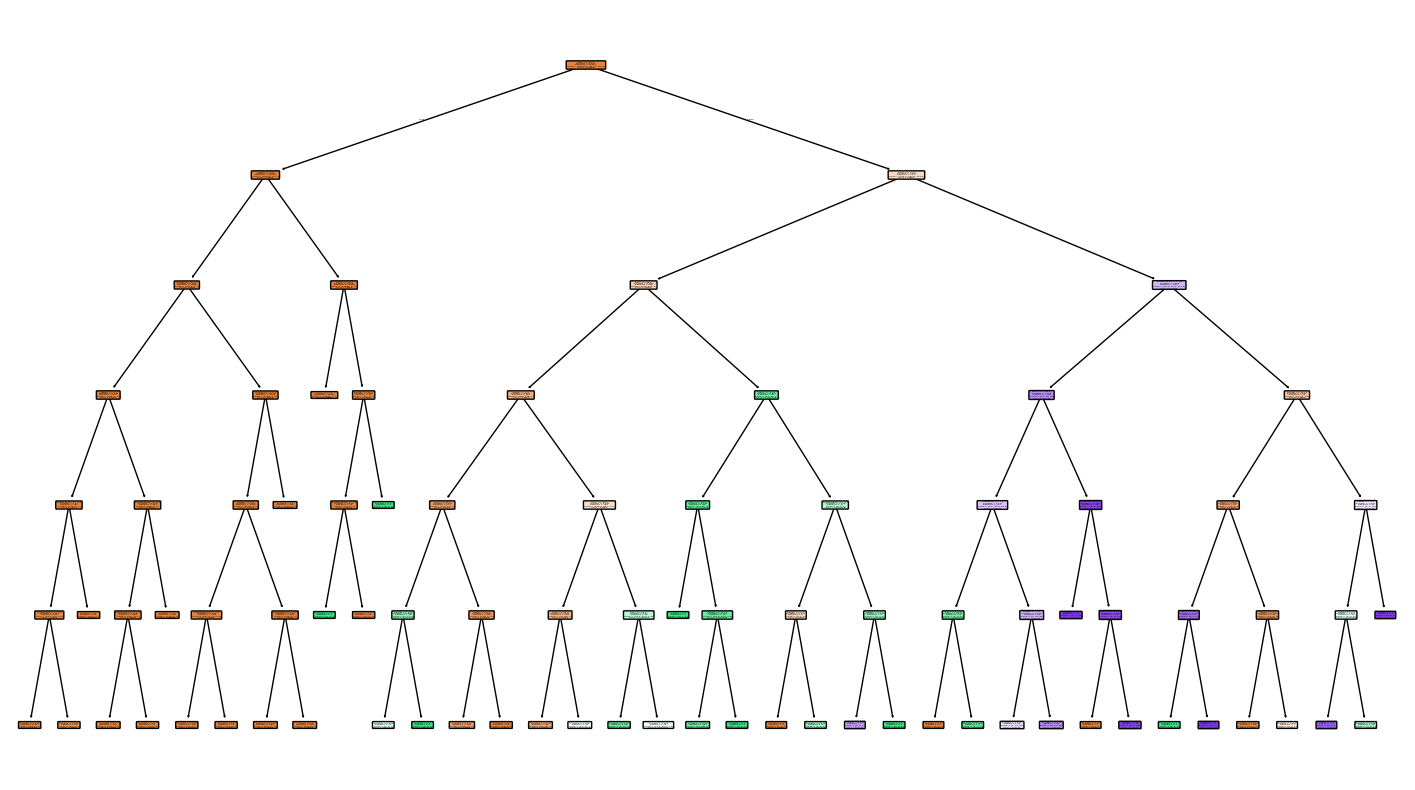

In [14]:
plt.figure(figsize=(18,10))
plot_tree(model_reussite, feature_names=X.columns, class_names=model_reussite.classes_, filled=True, rounded=True)
plt.show()

In [4]:
import joblib
joblib.dump(model_reussite,"Model_arbre_de_decision.pkl")
print ("Model enregistré")

NameError: name 'model_reussite' is not defined